# Bestand nach Stadtquartier und Nationalität
bev_bestand_jahr_quartier_nationalitaet_od3361

### Kurzbeschreibung
Bestand der wirtschaftlichen Wohnbevölkerung der Stadt Zürich nach Statistischem Stadtquartier und Nationalität.

Datum: 11.03.2026


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_quartier_nationalitaet_od3361

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_quartier_nationalitaet_od3361


### Importiere die notwendigen Packages

In [13]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [14]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Welche Python, Altair und Seaborn Version wird verwendet?

In [15]:
#base env 2025: Python 3.11.7
import ipykernel
print(ipykernel.__version__)

import sys
import platform
print("Python-Version:", sys.version)
print("Python-Implementierung:", platform.python_implementation())
print("Python-Build:", platform.python_build())
print("Python-Compiler:", platform.python_compiler())

print("Altair-Version:", alt.__version__)
print("Seaborn-Version:", sns.__version__)

6.29.3
Python-Version: 3.11.8 | packaged by Anaconda, Inc. | (main, Feb 26 2024, 21:34:05) [MSC v.1916 64 bit (AMD64)]
Python-Implementierung: CPython
Python-Build: ('main', 'Feb 26 2024 21:34:05')
Python-Compiler: MSC v.1916 64 bit (AMD64)
Altair-Version: 5.0.1
Seaborn-Version: 0.12.2


Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [16]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [17]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [18]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [19]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Paletten aus Zuericolors
Die Farbwerte habe ich aus R ausgelesen. Siehe dazu: `G:\sszsim\myR\zuericolors4python`

In [20]:
# Quantitative Paletten
zuericolors_qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
zuericolors_qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
zuericolors_qual12da= ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
# Divergente Paletten
zuericolors_div9val  =  ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A"] 
zuericolors_div9ntr  =  ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB"] 
# Geschlechter Paletten
zuericolors_gender3  =  ["#349894", "#FFD736", "#986AD5"] 
zuericolors_gender6origin  =  ["#00615D", "#349894", "#DA9C00", "#FFD736", "#5E359A", "#986AD5"] 
zuericolors_gender5wedding  =  ["#349894", "#FFD736", "#3431DE", "#B8B8B8", "#D6D6D6"] 
# Sequenzielle Paletten
zuericolors_seq9blu  =  ["#CADEFF", "#AEC2FF", "#93A6FF", "#778AFF", "#5B6EFF", "#4D59E2", "#3E44C5", "#302FA7", "#211A8A"] 
zuericolors_seq9red  =  ["#FED2EE", "#FEAED6", "#F589BE", "#F165A5", "#ED408D", "#D1307B", "#B52069", "#991056", "#7D0044"] 
zuericolors_seq9grn  =  ["#CFEED8", "#A8E0B3", "#81D18F", "#5BC36A", "#34B446", "#2A9A3C", "#208032", "#166529", "#0C4B1F"] 
zuericolors_seq9brn  =  ["#FCDDBB", "#F7BD8C", "#F39D5E", "#EE7D2F", "#EA5D00", "#C84E00", "#A53E00", "#832F00", "#611F00"]

#### Zeitvariabeln


In [21]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

In [22]:
package_name = "bev_bestand_jahr_quartier_nationalitaet_od3361"

In [23]:
data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV336OD3361"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_quartier_nationalitaet_od3361/download/BEV336OD3361.csv


 **Überprüfe die Metadaten:**

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_quartier_nationalitaet_od3361 

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/bev_bestand_jahr_quartier_nationalitaet_od3361 

data_source: web


In [24]:
data2betested.head(2).T

,0,1
StichtagDatJahr,1993-01-01 00:00:00,1993-01-01 00:00:00
QuarSort,11,11
QuarCd,11,11
QuarLang,Rathaus,Rathaus
NationHistSort,8100,8205
NationHistLang,Schweiz,Bulgarien
NationSort,8100,8205
NationLang,Schweiz,Bulgarien
RegionSort,13,17
RegionLang,Zentraleuropa,Südosteuropa


Berechne weitere Attribute falls notwendig

In [25]:
data2betested = (
    data2betested
    .copy()
    .assign(
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
QuarSort                        int64
QuarCd                          int64
QuarLang                       object
NationHistSort                  int64
NationHistLang                 object
NationSort                      int64
NationLang                     object
RegionSort                      int64
RegionLang                     object
KontinentSort                   int64
KontinentLang                  object
AnzBestWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_end               datetime64[ns]
Jahr_nbr                        int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [26]:
data_max_jahr = str(max(data2betested.Jahr).year)
data_min_jahr = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_jahr} und ein Maximumjahr von {data_max_jahr}")

Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2025


In [27]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2025


### Einfache Datentests

In [28]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 107029 entries, 107028 to 0
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   StichtagDatJahr      107029 non-null  datetime64[ns]
 1   QuarSort             107029 non-null  int64         
 2   QuarCd               107029 non-null  int64         
 3   QuarLang             107029 non-null  object        
 4   NationHistSort       107029 non-null  int64         
 5   NationHistLang       107029 non-null  object        
 6   NationSort           107029 non-null  int64         
 7   NationLang           107029 non-null  object        
 8   RegionSort           107029 non-null  int64         
 9   RegionLang           107029 non-null  object        
 10  KontinentSort        107029 non-null  int64         
 11  KontinentLang        107029 non-null  object        
 12  AnzBestWir           107029 non-null  int64         
 13  StichtagDatJahr_str

In [29]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 107,029 rows (observations) and 17 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [30]:
data2betested.describe()

,StichtagDatJahr,QuarSort,QuarCd,NationHistSort,NationSort,RegionSort,KontinentSort,AnzBestWir,Jahr,Jahr_end,Jahr_nbr
count,107029,107029,107029,107029,107029,107029,107029,107029,107029,107029,107029
mean,2009-10-07 21:11:01.648711936,69,69,8364,8364,28,2,121,2009-10-07 21:11:01.648711936,2010-10-07 03:04:29.926842112,2010
min,1993-01-01 00:00:00,11,11,8100,8100,11,1,1,1993-01-01 00:00:00,1993-12-31 00:00:00,1993
25%,2002-01-01 00:00:00,34,34,8242,8242,15,1,2,2002-01-01 00:00:00,2002-12-31 00:00:00,2002
50%,2010-01-01 00:00:00,72,72,8337,8337,24,2,6,2010-01-01 00:00:00,2010-12-31 00:00:00,2010
75%,2018-01-01 00:00:00,101,101,8506,8506,42,4,22,2018-01-01 00:00:00,2018-12-31 00:00:00,2018
max,2025-01-01 00:00:00,123,123,8999,8999,88,8,22720,2025-01-01 00:00:00,2025-12-31 00:00:00,2025
std,NaN,35,35,140,140,14,1,974,NaN,NaN,9


Welches sind die Zeilen ohne Werte bei AnzBestWir?

In [31]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,StichtagDatJahr,QuarSort,QuarCd,QuarLang,NationHistSort,NationHistLang,NationSort,...,KontinentSort,KontinentLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [32]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [33]:
data2betested.index.year.unique()

Index([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024, 2025],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [34]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number'))
except:
    print("No categorical data in dataset.")

,QuarLang,NationHistLang,NationLang,RegionLang,KontinentLang,StichtagDatJahr_str,Jahr,Jahr_end
count,107029,107029,107029,107029,107029,107029,107029,107029
unique,34,191,189,30,6,33,NaN,NaN
top,Altstetten,Grossbritannien,China,Südosteuropa,Europa,2024-01-01,NaN,NaN
freq,4138,1186,1165,9085,40650,3616,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2009-10-07 21:11:01.648711936,2010-10-07 03:04:29.926842368
min,NaN,NaN,NaN,NaN,NaN,NaN,1993-01-01 00:00:00,1993-12-31 00:00:00
25%,NaN,NaN,NaN,NaN,NaN,NaN,2002-01-01 00:00:00,2002-12-31 00:00:00
50%,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01 00:00:00,2010-12-31 00:00:00
75%,NaN,NaN,NaN,NaN,NaN,NaN,2018-01-01 00:00:00,2018-12-31 00:00:00
max,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:00:00,2025-12-31 00:00:00


Beschreibe numerische Attribute

In [35]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,QuarSort,QuarCd,NationHistSort,NationSort,RegionSort,KontinentSort,AnzBestWir,Jahr_nbr
count,"107,029","107,029","107,029","107,029","107,029","107,029","107,029","107,029"
mean,69,69,"8,364","8,364",28,2,121,"2,010"
std,35,35,140,140,14,1,974,9
min,11,11,"8,100","8,100",11,1,1,"1,993"
25%,34,34,"8,242","8,242",15,1,2,"2,002"
50%,72,72,"8,337","8,337",24,2,6,"2,010"
75%,101,101,"8,506","8,506",42,4,22,"2,018"
max,123,123,"8,999","8,999",88,8,"22,720","2,025"


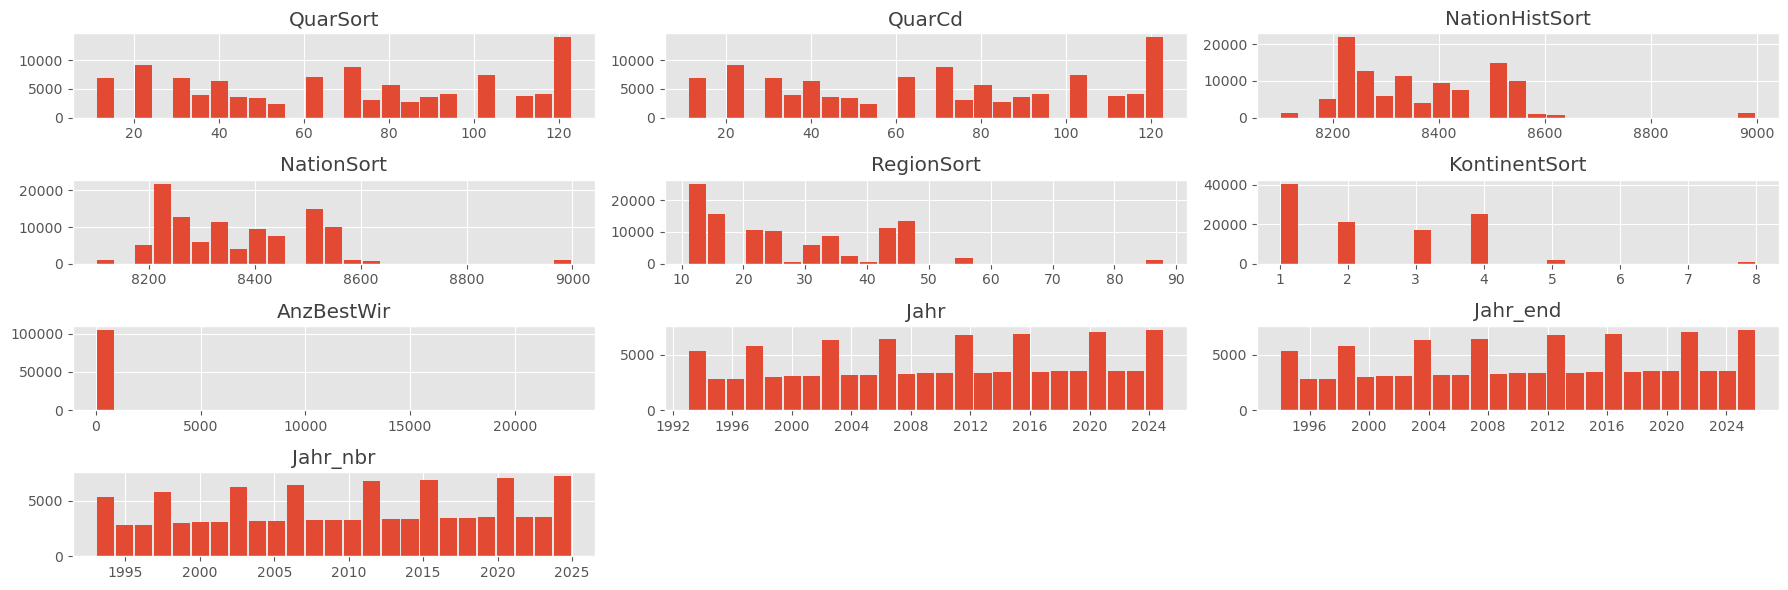

In [36]:
plt.style.use('ggplot')
params = {'text.color': (0.25, 0.25, 0.25), 'figure.figsize': [18, 6]}
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.")

### Gibt es Duplikate?

In [37]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,QuarSort,QuarCd,QuarLang,NationHistSort,NationHistLang,NationSort,NationLang,...,KontinentSort,KontinentLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [38]:
data2betested.isnull().sum()

QuarSort               0
QuarCd                 0
QuarLang               0
NationHistSort         0
NationHistLang         0
NationSort             0
NationLang             0
RegionSort             0
RegionLang             0
KontinentSort          0
KontinentLang          0
AnzBestWir             0
StichtagDatJahr_str    0
Jahr                   0
Jahr_end               0
Jahr_nbr               0
dtype: int64

In [39]:
# check missing values with missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [40]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,Jahr_end,sum_AnzBestWir
0,2025-01-01,2025,2025-12-31,452421
1,2024-01-01,2024,2024-12-31,448664
2,2023-01-01,2023,2023-12-31,447082


In [42]:
agg_quarlang = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['QuarLang', 'QuarSort']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('QuarLang', ascending=True) 
agg_quarlang.reset_index().head(5)

,QuarLang,QuarSort,sum_AnzBestWir
0,Affoltern,111,740544
1,Albisrieden,91,628585
2,Alt-Wiedikon,31,532736
3,Altstetten,92,1016795
4,City,14,28332


In [44]:
data2betested.columns

Index(['QuarSort', 'QuarCd', 'QuarLang', 'NationHistSort', 'NationHistLang', 'NationSort',
       'NationLang', 'RegionSort', 'RegionLang', 'KontinentSort', 'KontinentLang', 'AnzBestWir',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [43]:
agg_raum_zeit = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr_nbr', 'Jahr_end', 'QuarLang', 'QuarSort', 'NatLang', 'NatCd']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr_nbr', ascending=True) 
agg_raum_zeit.reset_index().head(3)

KeyError: 'NatLang'

In [ ]:
data2betested.reset_index().columns

### Pivotiere

In [ ]:
pivoted_df = data2betested.pivot_table(
    index='Jahr_nbr',
    columns= ('QuarLang', 'QuarSort', 'NatLang', 'NatCd'),
    values='AnzBestWir',
    aggfunc='sum'
)

pivoted_df = pivoted_df.sort_index(ascending=False)

print(pivoted_df.head(8).T)

### Visualisierungen nach Zeitausschnitten

#### Entwicklung Bestand nach Stadtquartier und Nationalität nach Stadtquartier

In [ ]:
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'QuarLang', 'QuarSort', 'NatLang', 'NatCd']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

In [ ]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('QuarLang', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_AnzBestWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Bestand'
    ,category = "QuarLang:N"
    ,category_beschriftung= 'Legende:'
    ,x_sort = None
    ,palette_scheme = None
    ,custom_palette = zuericolors_qual12br
    ,line_width = 1.1
    ,warning_status = "ignore"
    ,myTitle="Entwicklung Bestand nach Stadtquartier und Nationalität nach Stadtquartier, seit "+data_min_date
)
grafik1

##### Kombinierte Grafik in Altair

In [ ]:
top_row = alt.hconcat(grafik1, grafik1)
combined_chart = alt.vconcat(grafik1, grafik1, spacing=20)

final_chart = combined_chart.properties(
    title="Alle Teilgrafiken in einer zusammengesetzt:    ",
    background="#FDFDFD",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
final_chart = final_chart.resolve_scale(color='independent', shape='independent', size='independent')
final_chart

#### Barcharts mit Seaborn

In [ ]:
myAggBar = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr'] + ['QuarLang', 'QuarSort', 'NatLang', 'NatCd'] + ['Jahr', 'Jahr_end', 'Jahr_nbr']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True)

myAggBar.reset_index().head(3)

In [ ]:
sns.set_theme(style="whitegrid")

In [ ]:
myHist = sns.catplot(x="QuarLang"
            , y="sum_AnzBestWir"
            , kind="bar"
            , palette="pastel"
            , height=5
            , aspect=3
            , order=None, legend_out=True
            ,data=myAggBar.reset_index().query(f"Jahr_nbr == {data_max_jahr}")
           )
myHist.set_xticklabels(rotation=45)
myHist.set_xlabels('Stadtquartier', fontsize=11)
myHist.set_ylabels('Anz. Bestand', fontsize=11)

##### Stacked Bar Chart

In [ ]:
data = myAggBar.query("sum_AnzBestWir > 0").reset_index()
data_pivoted = data.pivot(index='Jahr_nbr', columns='QuarLang', values='sum_AnzBestWir').fillna(0)

colors = sns.color_palette("cubehelix", n_colors=len(data_pivoted.columns))
fig, ax = plt.subplots(figsize=(12, 6))
data_pivoted.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.9)
plt.title('Bestand nach Stadtquartier und Nationalität nach Stadtquartier seit '+data_min_date, fontsize=14)
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Anz. Bestand', fontsize=11)
plt.legend(title='Stadtquartier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Faced Grids

In [ ]:
data2betested.columns

In [ ]:
myFG = data2betested.reset_index().query('QuarSort != 0')
myFG.head(3)

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('QuarSort', ascending=True)
    ,col = "QuarLang"
    ,hue = "QuarLang"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzBestWir"
    ,ylabel= "Anz. Bestand"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Bestand nach Stadtquartier und Nationalität nach QuarLang, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [ ]:
attr2becolored = data2betested['QuarLang'].unique().tolist()
verfügbare_farben_zuericolors = zuericolors_qual12da+zuericolors_qual12br+zuericolors_qual12+zuericolors_div9ntr

farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(attr2becolored):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

print(farben_dict_zc)

In [ ]:
data2betested.columns

Jahre definieren, die dargestellt werden sollen

In [ ]:
int_data_max_year = data2betested.index.max().year

years = [
    int_data_max_year - 20,
    int_data_max_year
]
print(years)

##### Bestand nach Stadtquartier und Nationalität nach Stadtquartier und Jahr

In [ ]:
myTM = data2betested.loc[data_min_date:data_max_date].reset_index()

myTM.reset_index().head(2)

In [ ]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index().query("AnzBestWir>0")
    ,levels=['QuarLang', 'Jahr_nbr']
    ,values="AnzBestWir"
    ,color="AnzBestWir"
    ,color_discrete_map={'(?)':'lightgrey'}
    ,height=600
    ,width=1100
    ,myHeaderTitle="Bestand nach Stadtquartier und Nationalität nach Stadtquartier und Jahr, seit "+data_min_date
)
treeMap1

##### Bestand nach Stadtquartier und Nationalität nach Stadtquartier (aktuellstes Jahr)

In [ ]:
myTM2 = data2betested.loc[data_max_date]

myTM2.reset_index().head(2)

In [ ]:
treeMap2 = mypy_dv.plot_px_treemap(
    data=myTM2.reset_index().query("AnzBestWir>0")
    ,levels=['QuarLang']
    ,values="AnzBestWir"
    ,color="QuarLang"
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100
    ,myHeaderTitle="Bestand nach Stadtquartier und Nationalität nach Stadtquartier am "+data_max_date
)
treeMap2

## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link]()**

---------------------------------------------------------------------------